# Indian ALPR — End-to-End Pipeline

**Automatic License Plate Recognition for Indian vehicles**, built on
TensorFlow / Keras 3 + OpenCV. This notebook is a report-style, runnable
walkthrough of the full pipeline — an alternative to the CLI scripts in
`scripts/`.

Indian plates follow `‹state›‹district›‹series›‹number›` — e.g. `KL45C4411`,
`MH20TC830C`.

## The three stages

| Stage | What it does | Module |
|-------|--------------|--------|
| **1. Detection** | MobileNetV2 regresses one plate box `[xmin,ymin,xmax,ymax]` | `src/detection.py` |
| **2. Preprocessing** | crop → 4-point perspective warp → grayscale → CLAHE → `64×256` | `src/preprocessing.py` |
| **3. OCR** | CRNN (CNN→BiLSTM) + CTC reads the characters | `src/ocr.py` |

This notebook **imports** the stable data / preprocessing / loss utilities from
`src/`, but **inlines** the two model architectures and the end-to-end inference
so the core ML is visible here. Inlined `build_detector` / `build_crnn` are exact
mirrors of their `src/` counterparts.

> **Runtime note:** training defaults to a few epochs so the whole notebook runs
> on CPU in minutes. Bump `*_EPOCHS` in the config cell (and pick a GPU runtime)
> for real results. Each training section **loads a saved model if one exists**,
> so re-runs are fast.

## 1. Setup & configuration

Locate the project root (so relative paths work regardless of where the kernel
starts), quiet TensorFlow logs, and import the stack.

In [1]:
import os, sys
from pathlib import Path

# Detect Colab — controls how the code + data get onto the machine (next cell).
try:
    import google.colab  # noqa: F401
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

os.environ.setdefault("TF_CPP_MIN_LOG_LEVEL", "3")  # hide TF info/warning spam
print("IN_COLAB:", IN_COLAB)

IN_COLAB     : True
PROJECT_ROOT : /content


In [2]:
# Make the project code + data available, then put the repo root on sys.path.
if IN_COLAB:
    # 1) Dependencies.
    !pip install -q kagglehub tensorflow keras opencv-python pandas scikit-learn python-Levenshtein matplotlib tqdm

    # 2) Project code: clone this repo so `from src import ...` works on the VM.
    REPO_URL = "https://github.com/<your-username>/alpr-project.git"  # <-- EDIT ME
    assert "<your-username>" not in REPO_URL, "Set REPO_URL to your GitHub repo URL first."
    PROJECT_ROOT = Path("/content/alpr-project")
    if not (PROJECT_ROOT / "src").exists():
        !git clone "$REPO_URL" "$PROJECT_ROOT"

    # 3) Data: download from Kaggle (returns the local cache path).
    import kagglehub
    DATA_ROOT_OVERRIDE = kagglehub.dataset_download("saisirishan/indian-vehicle-dataset")
    print("Dataset downloaded to:", DATA_ROOT_OVERRIDE)
else:
    # Local: find the repo root (the directory that contains src/).
    def _find_root(start: Path) -> Path:
        for cand in [start.resolve(), *start.resolve().parents]:
            if (cand / "src").is_dir():
                return cand
        return start.resolve()
    PROJECT_ROOT = _find_root(Path.cwd())
    DATA_ROOT_OVERRIDE = None  # use the local data/ folder

os.chdir(PROJECT_ROOT)
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))
print("PROJECT_ROOT:", PROJECT_ROOT)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 153.3/153.3 kB 14.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 98.3 MB/s eta 0:00:00


100%|██████████| 178M/178M [00:12<00:00, 15.4MB/s] 

Extracting files...


Dataset downloaded to: /root/.cache/kagglehub/datasets/saisirishan/indian-vehicle-dataset/versions/1


In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import cv2
import keras
import tensorflow as tf
print(tf.config.list_physical_devices('GPU'))  # GPU sanity check
from keras import layers

# Stable building blocks reused from the repository.
from src import data, detection, ocr, preprocessing, pipeline  # noqa: F401

[PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


ModuleNotFoundError: No module named 'src'

### Configuration

Small epoch counts by default. Set `FORCE_RETRAIN_* = True` to retrain even when
a saved model exists.

In [20]:
# In Colab, the Kaggle download path overrides the local default (set in setup).
DATA_ROOT    = globals().get("DATA_ROOT_OVERRIDE") or "data"
DATASETS_DIR = Path("datasets")
DET_DIR      = DATASETS_DIR / "detection"
OCR_DIR      = DATASETS_DIR / "ocr"
MODELS_DIR   = Path("models")
DETECTOR_PATH = MODELS_DIR / "detection" / "detector.keras"
OCR_PATH      = MODELS_DIR / "ocr" / "crnn_best.keras"

# Detector schedule (each phase is a MAX budget — EarlyStopping cuts it short):
#   Phase 1 Huber warmup -> Phase 2 Huber+GIoU -> Phase 3 backbone fine-tune.
DET_WARMUP_EPOCHS      = 8
DET_WARMUP_LR          = 1e-4
DET_FINETUNE_EPOCHS    = 50
DET_FINETUNE_LR        = 3e-5
DET_BACKBONE_FT_EPOCHS = 30      # max budget; EarlyStopping cuts it short
DET_BACKBONE_FT_LR     = 1e-5

OCR_EPOCHS = 5
BATCH_SIZE = 16
FORCE_RETRAIN_DETECTOR = False
FORCE_RETRAIN_OCR      = False
SEED = 42

## 2. Stage 0 — Data

`src/data.py` parses the Pascal VOC annotations and:
- **filters noise** — keeps only strings matching the Indian-plate regexes
  (drops labels like `TERRANO`), skips `Zone.Identifier` sidecars and degenerate
  boxes;
- **deduplicates video frames** — `video_images` has the same plate across many
  frames, so we keep one sharpest (largest-box) frame per plate;
- **splits by plate identity** — whole plates are assigned to train/val/test so
  the *same* plate never leaks across splits (which would inflate metrics).

In [5]:
from collections import Counter
annotations = data.parse_voc(DATA_ROOT)
print(f"Clean annotations: {len(annotations)}")
Counter(a.source for a in annotations)

Clean annotations: 1592


Counter({'video_images': 633, 'State-wise_OLX': 551, 'google_images': 408})

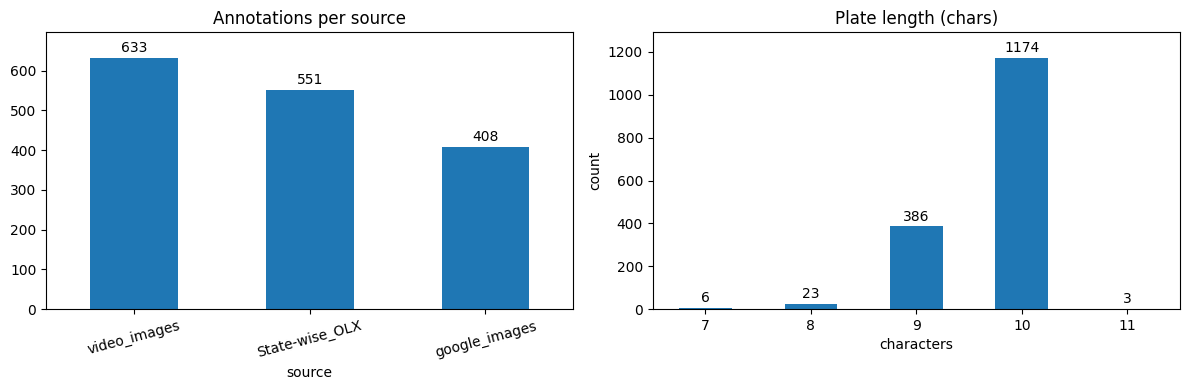

In [6]:
# Exploratory data analysis: per-source counts and plate-length distribution.
df = pd.DataFrame([
    {"source": a.source, "plate": a.plate_text,
     "len": len(a.plate_text), "state": a.plate_text[:2]}
    for a in annotations
])

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Annotations per source
df["source"].value_counts().plot.bar(
    ax=axes[0], title="Annotations per source", rot=15)
axes[0].bar_label(axes[0].containers[0], padding=2)

# Plate length
df["len"].value_counts().sort_index().plot.bar(
    ax=axes[1], title="Plate length (chars)", rot=0)
axes[1].set_xlabel("characters")
axes[1].set_ylabel("count")
axes[1].bar_label(axes[1].containers[0], padding=2)

axes[0].margins(y=0.1)
axes[1].margins(y=0.1)
plt.tight_layout(); plt.show()

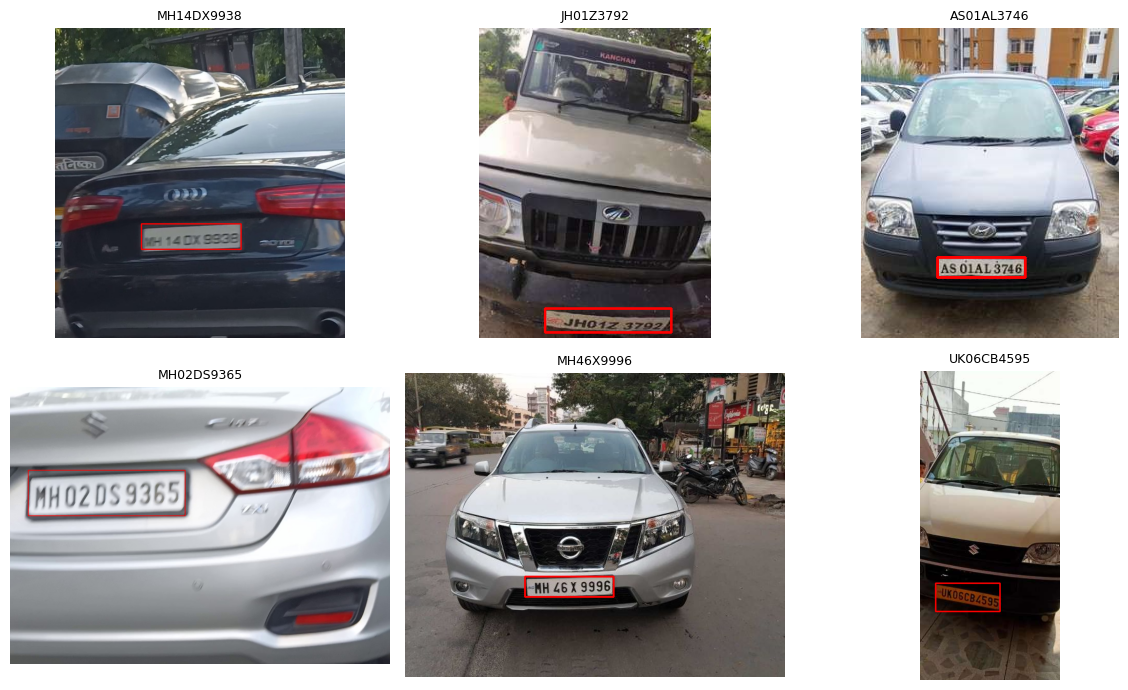

In [7]:
# A few sample images with their ground-truth boxes drawn.
import random
def show_image_with_box(ann, ax):
    img = cv2.cvtColor(cv2.imread(str(ann.image_path)), cv2.COLOR_BGR2RGB)
    cv2.rectangle(img, (ann.xmin, ann.ymin), (ann.xmax, ann.ymax), (255, 0, 0), 2)
    ax.imshow(img); ax.set_title(ann.plate_text, fontsize=9); ax.axis("off")

random.seed(SEED)
fig, axes = plt.subplots(2, 3, figsize=(12, 7))
for ann, ax in zip(random.sample(annotations, 6), axes.ravel()):
    show_image_with_box(ann, ax)
plt.tight_layout(); plt.show()

In [8]:
# Deduplicate video frames, then split by plate identity.
deduped = data.deduplicate(annotations)
splits = data.plate_aware_split(deduped, seed=SEED)
for k, v in splits.items():
    print(f"{k:5s}: {len(v)}")

sets = {k: {a.plate_text for a in v} for k, v in splits.items()}
leak = ((sets["train"] & sets["val"]) | (sets["train"] & sets["test"])
        | (sets["val"] & sets["test"]))
assert not leak, f"plate leakage detected: {leak}"
print("No plate leakage across splits.")

train: 881
val  : 103
test : 108
No plate leakage across splits.


In [9]:
# Build the per-stage datasets (skip if already present — load fallback).
det_ready = all((DET_DIR / f"{s}.csv").exists() for s in ("train", "val", "test"))
ocr_ready = (OCR_DIR / "labels.csv").exists()

if det_ready and ocr_ready:
    print("Datasets already present — skipping build.")
else:
    print("Building datasets ...")
    data.build_detection_manifest(splits, DET_DIR)
    data.build_ocr_dataset(splits, OCR_DIR)
    print("Done.")

ocr_labels = pd.read_csv(OCR_DIR / "labels.csv")
print("OCR samples:", len(ocr_labels))

Datasets already present — skipping build.
OCR samples: 1092


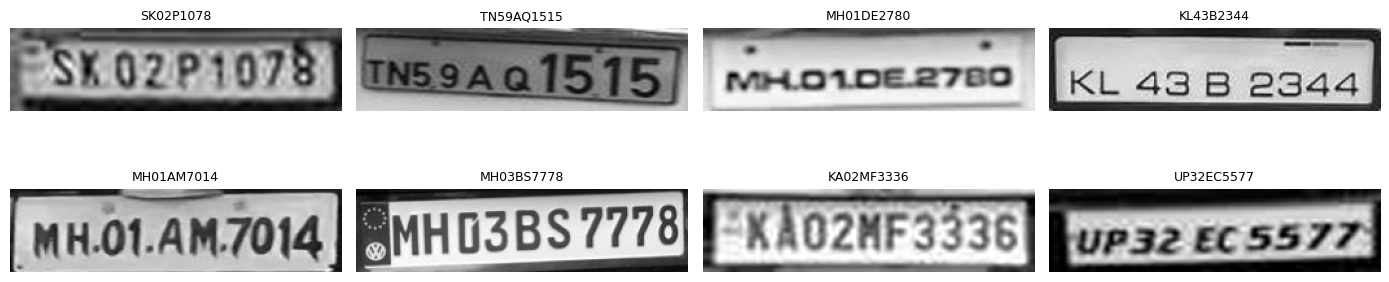

In [10]:
# Sample of the 64x256 grayscale plate crops the OCR model will read.
def grid_of_crops(df_split, n=8):
    rows = df_split.sample(min(n, len(df_split)), random_state=SEED)
    fig, axes = plt.subplots(2, 4, figsize=(14, 4))
    for (_, r), ax in zip(rows.iterrows(), axes.ravel()):
        img = cv2.imread(str(OCR_DIR / r["filename"]), cv2.IMREAD_GRAYSCALE)
        ax.imshow(img, cmap="gray"); ax.set_title(r["plate_text"], fontsize=9); ax.axis("off")
    plt.tight_layout(); plt.show()

grid_of_crops(ocr_labels[ocr_labels.split == "train"])

## 3. Stage 1 — Detection (bounding-box regression)

Rather than a full object detector, we frame detection as **regressing a single
normalized box** (there is exactly one plate per image). A pretrained
**MobileNetV2** backbone feeds a small head that outputs `[xmin, ymin, xmax,
ymax]` in `[0, 1]` (sigmoid). Training uses **Huber + (1 − GIoU)** loss with a
**mean-IoU** metric.

The architecture below mirrors `src/detection.py::build_detector`.

In [21]:
def build_detector(input_size=detection.INPUT_SIZE):
    """MobileNetV2 backbone + regression head (mirror of src/detection.py)."""
    backbone = keras.applications.MobileNetV2(
        weights="imagenet", include_top=False,
        input_shape=(input_size, input_size, 3),
    )
    inputs = keras.Input(shape=(input_size, input_size, 3))
    x = backbone(inputs, training=False)
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dense(256, activation="relu")(x)
    x = layers.Dropout(0.3)(x)
    outputs = layers.Dense(4, activation="sigmoid", name="box")(x)
    return keras.Model(inputs, outputs, name="plate_detector")

detector = build_detector()
detector.summary()

Model: "plate_detector"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_5 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_2      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 256)            │       327,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ box (Dense)                     │ (None, 4)              │         1,028 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,586,948 (9.87 MB)

 Trainable params: 2,552,836 (9.74 MB)

 Non-trainable params: 34,112 (133.25 KB)

In [23]:
# Three-phase detector training, or load a saved detector.
#
# GIoU from a cold start gives noisy gradients while boxes don't overlap, which
# can saturate the sigmoid into an inverted box where both losses lose their
# gradient (mean_iou stuck at 0). So: (1) warm up with Huber alone until boxes
# overlap, (2) refine with Huber+GIoU, (3) unfreeze the top of the backbone to
# push past the frozen-backbone ceiling. Each phase stops itself via EarlyStopping.
if DETECTOR_PATH.exists() and not FORCE_RETRAIN_DETECTOR:
    print("Loading existing detector ...")
    detector = detection.load_detector(DETECTOR_PATH)
    det_history = None
    det_phase_boundaries = []
else:
    DETECTOR_PATH.parent.mkdir(parents=True, exist_ok=True)
    detector = build_detector()  # fresh model
    # Augmentation intentionally off for now (added deliberately later).
    train_ds = detection.make_dataset(DET_DIR / "train.csv", BATCH_SIZE, augment=False, shuffle=True)
    val_ds   = detection.make_dataset(DET_DIR / "val.csv", BATCH_SIZE)
    def ckpt():
        return keras.callbacks.ModelCheckpoint(str(DETECTOR_PATH), save_best_only=True,
                                               monitor="val_mean_iou", mode="max")
    def early():
        return keras.callbacks.EarlyStopping(monitor="val_mean_iou", mode="max",
                                             patience=5, restore_best_weights=True)

    # Phase 1 — Huber only: stable warmup so boxes start overlapping the targets.
    print(f"Phase 1: Huber warmup — {DET_WARMUP_EPOCHS} epochs @ lr={DET_WARMUP_LR}")
    detector.compile(optimizer=keras.optimizers.Adam(DET_WARMUP_LR),
                     loss=keras.losses.Huber(), metrics=[detection.MeanIoU()])
    h1 = detector.fit(train_ds, validation_data=val_ds,
                      epochs=DET_WARMUP_EPOCHS, callbacks=[ckpt()])

    # Gate: regression should give a non-zero mean IoU within the first epoch.
    if not h1.history["mean_iou"][0] > 0:
        raise RuntimeError(
            f"Warmup failed: mean_iou={h1.history['mean_iou'][0]} after epoch 1 "
            "(expected > 0). Stopping before the GIoU phase — investigate.")

    # Phase 2 — Huber + GIoU: refine localisation at a lower LR.
    print(f"Phase 2: Huber+GIoU fine-tune — up to {DET_FINETUNE_EPOCHS} epochs @ lr={DET_FINETUNE_LR}")
    detector.compile(optimizer=keras.optimizers.Adam(DET_FINETUNE_LR),
                     loss=detection.detector_loss, metrics=[detection.MeanIoU()])
    h2 = detector.fit(train_ds, validation_data=val_ds,
                      epochs=DET_FINETUNE_EPOCHS, callbacks=[ckpt(), early()])

    # Phase 3 — unfreeze the top ~20 backbone layers (BatchNorm stays in inference
    # mode) and fine-tune at a very low LR to push past the frozen ceiling.
    backbone = next(l for l in detector.layers if isinstance(l, keras.Model))
    backbone.trainable = True
    for layer in backbone.layers[:-20]:        # re-freeze everything below the top ~20
        layer.trainable = False
    for layer in backbone.layers:              # keep ALL BatchNorm in inference mode
        if isinstance(layer, keras.layers.BatchNormalization):
            layer.trainable = False
    n_trainable = sum(l.trainable for l in backbone.layers)
    print(f"Phase 3: backbone fine-tune — up to {DET_BACKBONE_FT_EPOCHS} epochs @ "
          f"lr={DET_BACKBONE_FT_LR} ({n_trainable}/{len(backbone.layers)} backbone layers trainable)")
    detector.compile(optimizer=keras.optimizers.Adam(DET_BACKBONE_FT_LR),
                     loss=detection.detector_loss, metrics=[detection.MeanIoU()])
    h3 = detector.fit(train_ds, validation_data=val_ds,
                      epochs=DET_BACKBONE_FT_EPOCHS, callbacks=[ckpt(), early()])

    # Combine all phases' histories; record boundaries (warmup->P2, P2->P3) for plots.
    det_history = {k: h1.history.get(k, []) + h2.history.get(k, []) + h3.history.get(k, [])
                   for k in ("loss", "val_loss", "mean_iou", "val_mean_iou")}
    det_phase_boundaries = [DET_WARMUP_EPOCHS,
                            DET_WARMUP_EPOCHS + len(h2.history["loss"])]

    # Best validation IoU across the whole run (1-indexed epoch).
    vmi = det_history["val_mean_iou"]
    best_ep = int(np.argmax(vmi)) + 1
    print(f"\nBest val_mean_iou = {max(vmi):.4f} at epoch {best_ep} of {len(vmi)} (all phases).")

Phase 1: Huber warmup — 8 epochs @ lr=0.0001
Epoch 1/8
56/56 ━━━━━━━━━━━━━━━━━━━━ 40s 423ms/step - loss: 0.0156 - mean_iou: 0.0748 - val_loss: 0.0140 - val_mean_iou: 0.0421
Epoch 2/8
56/56 ━━━━━━━━━━━━━━━━━━━━ 22s 398ms/step - loss: 0.0062 - mean_iou: 0.1338 - val_loss: 0.0140 - val_mean_iou: 0.0414
Epoch 3/8
56/56 ━━━━━━━━━━━━━━━━━━━━ 23s 405ms/step - loss: 0.0044 - mean_iou: 0.1694 - val_loss: 0.0121 - val_mean_iou: 0.0436
Epoch 4/8
56/56 ━━━━━━━━━━━━━━━━━━━━ 23s 416ms/step - loss: 0.0033 - mean_iou: 0.1933 - val_loss: 0.0114 - val_mean_iou: 0.0476
Epoch 5/8
56/56 ━━━━━━━━━━━━━━━━━━━━ 23s 413ms/step - loss: 0.0031 - mean_iou: 0.2052 - val_loss: 0.0110 - val_mean_iou: 0.0493
Epoch 6/8
56/56 ━━━━━━━━━━━━━━━━━━━━ 24s 422ms/step - loss: 0.0024 - mean_iou: 0.2242 - val_loss: 0.0097 - val_mean_iou: 0.0675
Epoch 7/8
56/56 ━━━━━━━━━━━━━━━━━━━━ 24s 422ms/step - loss: 0.0024 - mean_iou: 0.2273 - val_loss: 0.0096 - val_mean_iou: 0.0674
Epoch 8/8
56/56 ━━━━━━━━━━━━━━━━━━━━ 23s 408ms/step - loss:

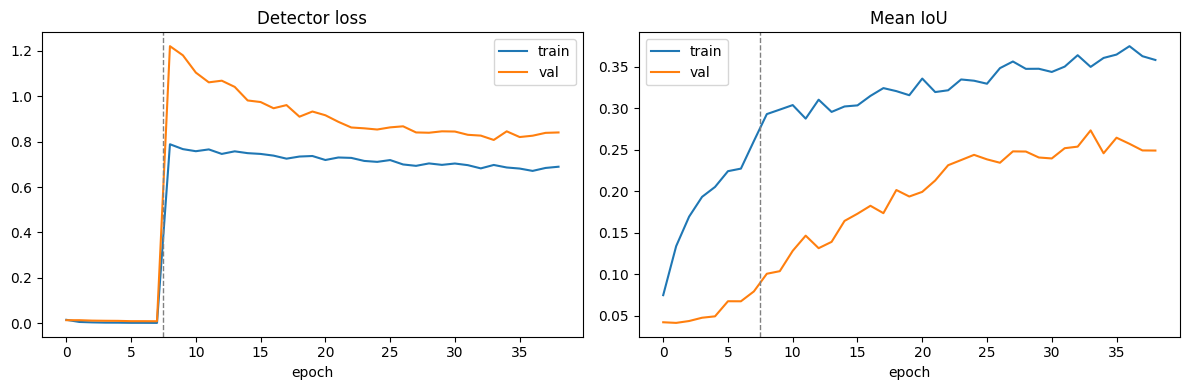

In [24]:
# Training curves across all phases (dashed lines = phase boundaries).
if det_history is not None:
    h = det_history
    fig, ax = plt.subplots(1, 2, figsize=(12, 4))
    ax[0].plot(h["loss"], label="train"); ax[0].plot(h["val_loss"], label="val")
    ax[0].set_title("Detector loss"); ax[0].set_xlabel("epoch"); ax[0].legend()
    ax[1].plot(h["mean_iou"], label="train"); ax[1].plot(h["val_mean_iou"], label="val")
    ax[1].set_title("Mean IoU"); ax[1].set_xlabel("epoch"); ax[1].legend()
    for a in ax:
        for b in det_phase_boundaries:
            a.axvline(b - 0.5, ls="--", c="gray", lw=1)
    plt.tight_layout(); plt.show()
else:
    print("Loaded a saved model — no training history to plot.")

In [16]:
# Evaluate on the test split: mean IoU and accuracy at IoU >= 0.5.
test_ds = detection.make_dataset(DET_DIR / "test.csv", BATCH_SIZE)
ious = []
for imgs, boxes in test_ds:
    preds = detector.predict(imgs, verbose=0)
    for p, t in zip(preds, boxes.numpy()):
        x0, y0 = max(p[0], t[0]), max(p[1], t[1])
        x1, y1 = min(p[2], t[2]), min(p[3], t[3])
        inter = max(0.0, x1 - x0) * max(0.0, y1 - y0)
        ap = max(0.0, p[2]-p[0]) * max(0.0, p[3]-p[1])
        at = max(0.0, t[2]-t[0]) * max(0.0, t[3]-t[1])
        ious.append(inter / (ap + at - inter + 1e-7))
ious = np.array(ious)
print(f"Test mean IoU: {ious.mean():.3f} | accuracy@IoU>=0.5: {(ious >= 0.5).mean():.3f}")

Test mean IoU: 0.137 | accuracy@IoU>=0.5: 0.019


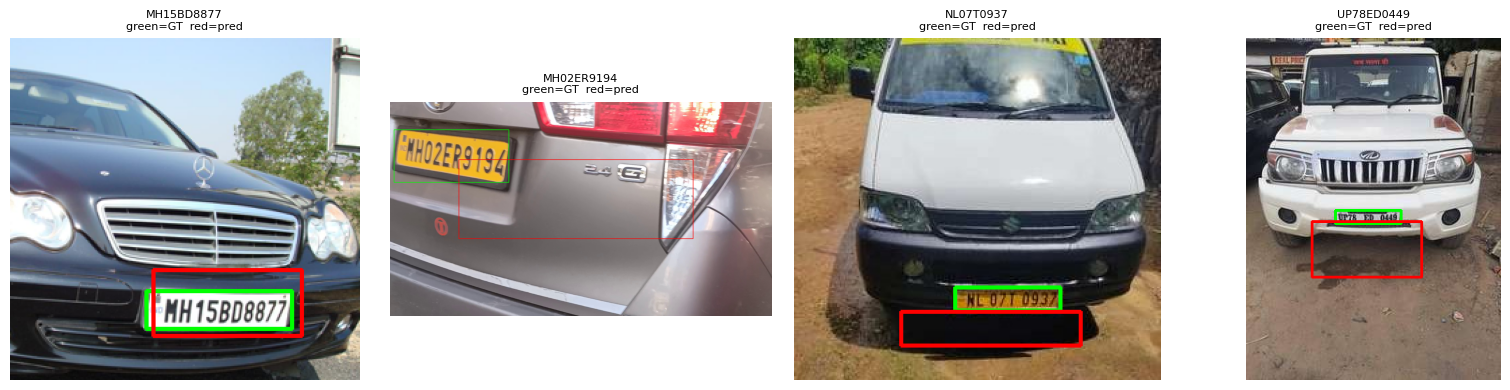

In [17]:
# Visualize predicted (red) vs ground-truth (green) boxes.
test_df = pd.read_csv(DET_DIR / "test.csv")
fig, axes = plt.subplots(1, 4, figsize=(16, 4))
for (_, r), ax in zip(test_df.sample(4, random_state=SEED).iterrows(), axes.ravel()):
    img = cv2.imread(r["image_path"]); h, w = img.shape[:2]
    rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    gt = (int(r.xmin_n*w), int(r.ymin_n*h), int(r.xmax_n*w), int(r.ymax_n*h))
    cv2.rectangle(rgb, gt[:2], gt[2:], (0, 255, 0), 2)
    px = detection.detect_plate(img, detector)
    cv2.rectangle(rgb, px[:2], px[2:], (255, 0, 0), 2)
    ax.imshow(rgb); ax.set_title(f"{r.plate_text}\ngreen=GT  red=pred", fontsize=8); ax.axis("off")
plt.tight_layout(); plt.show()

## Why the detector collapsed (and the fix)

**Symptom:** loss decreased (1.14 → 1.07) but `mean_iou` was pinned at exactly 0
from epoch 1. Predicted boxes collapsed to a constant `[~1, ~1, ~0, ~0]` for every
image — an *inverted* box (xmax < xmin).

**Root cause — a dead gradient at the inverted box:**
- In `giou_loss`, the `tf.maximum(0.0, ...)` clamps clip intersection/areas to 0
  once the box inverts. GIoU flatlines at 1.0, so its gradient is 0.
- The final `sigmoid` saturates at 1.0000000, so the Huber gradient gets multiplied
  by `σ(1−σ) ≈ 0` in the chain rule and also vanishes.
- Both loss terms lose gradient at the same point → the model is stuck, no signal
  pulls it out. (Confirmed: loss ≈ 1.0 GIoU + ~0.18 Huber = the observed ~1.19.)

**What pushed it there:** with a 1:1 Huber+GIoU weight, early on (random,
non-overlapping boxes) GIoU produces noisy gradients that shove the coordinates to
the extremes and saturate the sigmoid *before* Huber can pull them toward the target.

**Verification:**
- Fresh model, Huber-only, lr=1e-4 → preds land near targets, valid boxes. ✓
- `giou_loss` sanity check: identical→5e-6 (≈0), disjoint→1.875. Formula is correct,
  so this is GIoU cold-start, not a bug.

**Fix — warmup:** train on Huber alone until boxes overlap the targets, then
re-compile with `detector_loss` (Huber + GIoU) at a lower lr to refine. GIoU only
contributes once it's in its useful (overlapping) regime.

## 4. Stage 2 — Preprocessing

The detector gives an axis-aligned box, but the plate may be tilted. For each
crop we try to recover the plate's four corners (Canny → contours →
`approxPolyDP`) and apply a **perspective warp** to rectify it (falling back to a
plain resize when no quad is found), then convert to grayscale and apply
**CLAHE** for local contrast — producing the clean `64×256` image the OCR model
expects.

In [ ]:
# Show crop -> detected corners -> warped -> final CLAHE grayscale.
fig, axes = plt.subplots(3, 4, figsize=(14, 9))
for row, (_, r) in enumerate(test_df.sample(3, random_state=1).iterrows()):
    img = cv2.imread(r["image_path"]); h, w = img.shape[:2]
    bbox = (int(r.xmin_n*w), int(r.ymin_n*h), int(r.xmax_n*w), int(r.ymax_n*h))
    x0, y0, x1, y1 = bbox
    crop = img[max(0, y0):y1, max(0, x0):x1]
    corners = preprocessing.find_plate_corners(crop)

    axes[row, 0].imshow(cv2.cvtColor(crop, cv2.COLOR_BGR2RGB)); axes[row, 0].set_title("crop")
    vis = cv2.cvtColor(crop.copy(), cv2.COLOR_BGR2RGB)
    if corners is not None:
        cv2.polylines(vis, [corners.astype(int)], True, (255, 0, 0), 2)
    axes[row, 1].imshow(vis); axes[row, 1].set_title("corners" if corners is not None else "no corners")
    if corners is not None:
        warped = preprocessing.four_point_transform(crop, corners)
        axes[row, 2].imshow(cv2.cvtColor(warped, cv2.COLOR_BGR2RGB))
    else:
        axes[row, 2].imshow(cv2.cvtColor(cv2.resize(crop, (256, 64)), cv2.COLOR_BGR2RGB))
    axes[row, 2].set_title("rectified")
    axes[row, 3].imshow(preprocessing.preprocess_plate(img, bbox), cmap="gray")
    axes[row, 3].set_title("grayscale + CLAHE")
    for c in range(4):
        axes[row, c].axis("off")
plt.tight_layout(); plt.show()

## 5. Stage 3 — OCR (CRNN + CTC)

A **CRNN** reads the plate: a 4-block CNN turns the `64×256` image into a length
`T=32` sequence of feature vectors (the width axis becomes time), two **BiLSTM**
layers model the sequence, and a Dense layer scores each timestep over the **37
classes** (`A–Z`, `0–9`, plus a CTC blank at index 0). **CTC** loss aligns this
sequence to the variable-length text without per-character position labels.

> The Dense layer outputs **linear logits, not softmax** — both
> `keras.losses.CTC` and `keras.ops.ctc_decode` apply softmax internally.

The architecture below mirrors `src/ocr.py::build_crnn`.

In [ ]:
def build_crnn():
    """CRNN: 4-block CNN -> 2x BiLSTM -> Dense logits (mirror of src/ocr.py)."""
    inputs = keras.Input(shape=(ocr.OCR_HEIGHT, ocr.OCR_WIDTH, 1), name="image")
    x = inputs
    # Each block halves H; only the first three also halve W, so the time axis
    # (width) stays long: H 64->4 (/16), W 256->32 (/8) => TIME_STEPS = 32.
    for f, pool in zip([64, 128, 256, 256], [(2, 2), (2, 2), (2, 2), (2, 1)]):
        x = layers.Conv2D(f, 3, padding="same", use_bias=False)(x)
        x = layers.BatchNormalization()(x)
        x = layers.Activation("relu")(x)
        x = layers.MaxPooling2D(pool)(x)
    x = layers.Permute((2, 1, 3))(x)             # width -> time axis
    x = layers.Reshape((ocr.TIME_STEPS, -1))(x)  # (B, 32, 1024)
    x = layers.Dropout(0.25)(x)
    x = layers.Bidirectional(layers.LSTM(256, return_sequences=True))(x)
    x = layers.Dropout(0.25)(x)
    x = layers.Bidirectional(layers.LSTM(256, return_sequences=True))(x)
    x = layers.Dropout(0.25)(x)
    outputs = layers.Dense(ocr.NUM_CLASSES, name="logits")(x)  # linear logits
    return keras.Model(inputs, outputs, name="crnn")

crnn = build_crnn()
assert crnn.output_shape == (None, ocr.TIME_STEPS, ocr.NUM_CLASSES)
crnn.summary()

In [ ]:
# Train, or load a saved OCR model if one exists.
if OCR_PATH.exists() and not FORCE_RETRAIN_OCR:
    print("Loading existing OCR model ...")
    crnn = ocr.load_ocr_model(OCR_PATH)
    ocr_history = None
else:
    print(f"Training OCR for {OCR_EPOCHS} epochs ...")
    OCR_PATH.parent.mkdir(parents=True, exist_ok=True)
    train_ds = ocr.make_dataset(OCR_DIR / "labels.csv", "train", 32, augment=True, shuffle=True)
    val_ds   = ocr.make_dataset(OCR_DIR / "labels.csv", "val", 32)
    crnn.compile(optimizer=keras.optimizers.Adam(1e-3), loss=keras.losses.CTC())
    ckpt = keras.callbacks.ModelCheckpoint(str(OCR_PATH), save_best_only=True, monitor="val_loss")
    ocr_history = crnn.fit(train_ds, validation_data=val_ds,
                           epochs=OCR_EPOCHS, callbacks=[ckpt])

In [ ]:
if ocr_history is not None:
    plt.figure(figsize=(6, 4))
    plt.plot(ocr_history.history["loss"], label="train")
    plt.plot(ocr_history.history["val_loss"], label="val")
    plt.title("CTC loss"); plt.xlabel("epoch"); plt.legend(); plt.show()
else:
    print("Loaded a saved model — no training history to plot.")

In [ ]:
# Evaluate OCR on the test crops: exact-match and character error rate (CER).
import Levenshtein
truths = ocr_labels[ocr_labels.split == "test"]["plate_text"].tolist()
preds = []
for imgs, _ in ocr.make_dataset(OCR_DIR / "labels.csv", "test", 32):
    preds.extend(ocr.ctc_greedy_decode(crnn.predict(imgs, verbose=0)))

exact = np.mean([p == t for p, t in zip(preds, truths)])
cer = np.mean([Levenshtein.distance(p, t) / max(1, len(t)) for p, t in zip(preds, truths)])
print(f"OCR exact-match: {exact:.3f} | CER: {cer:.3f}")

In [ ]:
# Sample predictions on test crops (✓ correct, ✗ wrong).
fig, axes = plt.subplots(2, 4, figsize=(14, 4))
for (_, r), ax in zip(ocr_labels[ocr_labels.split == "test"].sample(8, random_state=SEED).iterrows(), axes.ravel()):
    img = cv2.imread(str(OCR_DIR / r["filename"]), cv2.IMREAD_GRAYSCALE)
    x = (img.astype("float32") / 255.0)[None, ..., None]
    pred = ocr.ctc_greedy_decode(crnn.predict(x, verbose=0))[0]
    mark = "OK" if pred == r["plate_text"] else "X"
    ax.imshow(img, cmap="gray")
    ax.set_title(f"[{mark}] {pred}\ngt: {r['plate_text']}", fontsize=8); ax.axis("off")
plt.tight_layout(); plt.show()

## 6. End-to-end pipeline

Chaining the three stages: **image → detect box → preprocess → read text**. The
`run_alpr` function below mirrors `src/pipeline.py::ALPRPipeline.run`; the packaged
version can be used directly as:

```python
pipe = pipeline.ALPRPipeline(DETECTOR_PATH, OCR_PATH)
pipe.run("path/to/car.jpg")
```

In [ ]:
def run_alpr(image_path, detector, crnn):
    """Detect -> preprocess -> read (mirror of src/pipeline.py::ALPRPipeline.run)."""
    img = cv2.imread(str(image_path))
    bbox = detection.detect_plate(img, detector)
    crop = preprocessing.preprocess_plate(img, bbox)
    x = (crop.astype("float32") / 255.0)[None, ..., None]
    text = ocr.ctc_greedy_decode(crnn.predict(x, verbose=0))[0]
    return bbox, crop, text

In [ ]:
# Visualize the full pipeline on a few test images.
fig, axes = plt.subplots(2, 4, figsize=(16, 6))
for i, (_, r) in enumerate(test_df.sample(4, random_state=7).iterrows()):
    bbox, crop, text = run_alpr(r["image_path"], detector, crnn)
    img = cv2.cvtColor(cv2.imread(r["image_path"]), cv2.COLOR_BGR2RGB)
    cv2.rectangle(img, bbox[:2], bbox[2:], (255, 0, 0), 2)
    axes[0, i].imshow(img); axes[0, i].set_title(f"pred: {text}\ngt: {r.plate_text}", fontsize=8); axes[0, i].axis("off")
    axes[1, i].imshow(crop, cmap="gray"); axes[1, i].set_title("preprocessed", fontsize=8); axes[1, i].axis("off")
plt.tight_layout(); plt.show()

In [ ]:
# Full-plate exact-match on PREDICTED boxes, plus a per-state breakdown.
from collections import defaultdict
correct = total = 0
per_state = defaultdict(lambda: [0, 0])
for _, r in test_df.iterrows():
    _, _, text = run_alpr(r["image_path"], detector, crnn)
    true = r["plate_text"]; total += 1; per_state[true[:2]][1] += 1
    if text == true:
        correct += 1; per_state[true[:2]][0] += 1

print(f"End-to-end full-plate exact-match: {correct}/{total} = {correct/total:.3f}\n")
print("Per-state (correct/total):")
for s in sorted(per_state):
    c, t = per_state[s]
    print(f"  {s}: {c}/{t}")

## 7. Results & conclusion

**Pipeline:** detection (MobileNetV2 box regression) → OpenCV rectification →
CRNN+CTC recognition, all in TensorFlow/Keras 3.

**Targets** (full training, GPU): detection mean IoU > ~0.85; OCR exact-match
> 80% / CER < 5%. With the few-epoch defaults here the numbers are only
indicative — increase `*_EPOCHS` and use a GPU runtime for representative results.

**Limitations**
- Small, skewed dataset (~1.1k plates; `video_images` is mostly Maharashtra).
- Single plate per image assumed (box regression, not multi-object detection).
- Many `State-wise_OLX` images are low-resolution thumbnails, which caps OCR quality.

**Future work**
- Swap box regression for a true detector if multi-plate images appear.
- Stronger OCR augmentation / a larger backbone; beam-search CTC decoding.
- Per-state class balancing and harder-negative mining.